In [ ]:
import requests
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [ ]:
url = "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"

In [ ]:
response = requests.get(url)
response

<Response [200]>

In [ ]:
response.status_code

200

In [ ]:
data = response.json()

In [ ]:
data.keys()

dict_keys(['total_count', 'incomplete_results', 'items'])

In [ ]:
repositories = data["items"]
len(repositories)

100

In [ ]:
repositories[0]

{'id': 45717250,
 'node_id': 'MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==',
 'name': 'tensorflow',
 'full_name': 'tensorflow/tensorflow',
 'private': False,
 'owner': {'login': 'tensorflow',
  'id': 15658638,
  'node_id': 'MDEyOk9yZ2FuaXphdGlvbjE1NjU4NjM4',
  'avatar_url': 'https://avatars.githubusercontent.com/u/15658638?v=4',
  'gravatar_id': '',
  'url': 'https://api.github.com/users/tensorflow',
  'html_url': 'https://github.com/tensorflow',
  'followers_url': 'https://api.github.com/users/tensorflow/followers',
  'following_url': 'https://api.github.com/users/tensorflow/following{/other_user}',
  'gists_url': 'https://api.github.com/users/tensorflow/gists{/gist_id}',
  'starred_url': 'https://api.github.com/users/tensorflow/starred{/owner}{/repo}',
  'subscriptions_url': 'https://api.github.com/users/tensorflow/subscriptions',
  'organizations_url': 'https://api.github.com/users/tensorflow/orgs',
  'repos_url': 'https://api.github.com/users/tensorflow/repos',
  'events_url': 'https://api.git

In [ ]:
repositories = data["items"]

In [ ]:
df = pd.DataFrame(repositories)
df.head()

,id,node_id,name,full_name,private,owner,html_url,description,fork,url,...,web_commit_signoff_required,has_pull_requests,pull_request_creation_policy,topics,visibility,forks,open_issues,watchers,default_branch,score
0,45717250,MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==,tensorflow,tensorflow/tensorflow,False,"{'login': 'tensorflow', 'id': 15658638, 'node_...",https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,False,https://api.github.com/repos/tensorflow/tensor...,...,False,True,all,"[deep-learning, deep-neural-networks, distribu...",public,76098,2932,197330,master,1.0
1,155220641,MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=,transformers,huggingface/transformers,False,"{'login': 'huggingface', 'id': 25720743, 'node...",https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,False,https://api.github.com/repos/huggingface/trans...,...,False,True,all,"[audio, deep-learning, deepseek, gemma, glm, h...",public,34325,2400,164344,main,1.0
2,343965132,MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=,ML-For-Beginners,microsoft/ML-For-Beginners,False,"{'login': 'microsoft', 'id': 6154722, 'node_id...",https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",False,https://api.github.com/repos/microsoft/ML-For-...,...,False,True,all,"[data-science, education, machine-learning, ma...",public,22038,13,89688,main,1.0
3,145553672,MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=,funNLP,fighting41love/funNLP,False,"{'login': 'fighting41love', 'id': 11475294, 'n...",https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,False,https://api.github.com/repos/fighting41love/fu...,...,False,True,all,[],public,15272,52,82598,master,1.0
4,21872392,MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==,awesome-machine-learning,josephmisiti/awesome-machine-learning,False,"{'login': 'josephmisiti', 'id': 246302, 'node_...",https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,False,https://api.github.com/repos/josephmisiti/awes...,...,False,True,all,[],public,15619,26,74119,master,1.0


In [ ]:
df.shape

(100, 82)

In [ ]:
df.columns

Index(['id', 'node_id', 'name', 'full_name', 'private', 'owner', 'html_url',
       'description', 'fork', 'url', 'forks_url', 'keys_url',
       'collaborators_url', 'teams_url', 'hooks_url', 'issue_events_url',
       'events_url', 'assignees_url', 'branches_url', 'tags_url', 'blobs_url',
       'git_tags_url', 'git_refs_url', 'trees_url', 'statuses_url',
       'languages_url', 'stargazers_url', 'contributors_url',
       'subscribers_url', 'subscription_url', 'commits_url', 'git_commits_url',
       'comments_url', 'issue_comment_url', 'contents_url', 'compare_url',
       'merges_url', 'archive_url', 'downloads_url', 'issues_url', 'pulls_url',
       'milestones_url', 'notifications_url', 'labels_url', 'releases_url',
       'deployments_url', 'created_at', 'updated_at', 'pushed_at', 'git_url',
       'ssh_url', 'clone_url', 'svn_url', 'homepage', 'size',
       'stargazers_count', 'watchers_count', 'language', 'has_issues',
       'has_projects', 'has_downloads', 'has_wiki', 'has

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 82 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            100 non-null    int64  
 1   node_id                       100 non-null    object 
 2   name                          100 non-null    object 
 3   full_name                     100 non-null    object 
 4   private                       100 non-null    bool   
 5   owner                         100 non-null    object 
 6   html_url                      100 non-null    object 
 7   description                   100 non-null    object 
 8   fork                          100 non-null    bool   
 9   url                           100 non-null    object 
 10  forks_url                     100 non-null    object 
 11  keys_url                      100 non-null    object 
 12  collaborators_url             100 non-null    object 
 13  teams_

In [ ]:
df.describe()

,id,size,stargazers_count,watchers_count,forks_count,open_issues_count,forks,open_issues,watchers,score
count,1.000000e+02,1.000000e+02,100.000000,100.000000,100.00000,100.000000,100.00000,100.000000,100.000000,100.0
mean,1.596683e+08,2.305578e+05,20822.230000,20822.230000,4814.89000,265.530000,4814.89000,265.530000,20822.230000,1.0
std,1.558514e+08,5.380686e+05,27310.342108,27310.342108,8769.83301,589.995916,8769.83301,589.995916,27310.342108,0.0
min,2.659950e+05,7.000000e+00,7483.000000,7483.000000,498.00000,0.000000,498.00000,0.000000,7483.000000,1.0
25%,6.347759e+07,6.931250e+03,9416.750000,9416.750000,1782.25000,12.000000,1782.25000,12.000000,9416.750000,1.0
50%,1.131206e+08,3.123300e+04,13475.500000,13475.500000,2879.50000,32.500000,2879.50000,32.500000,13475.500000,1.0
75%,1.957467e+08,1.603765e+05,20251.250000,20251.250000,4436.00000,183.500000,4436.00000,183.500000,20251.250000,1.0
max,8.025451e+08,3.028249e+06,197330.000000,197330.000000,76098.00000,2932.000000,76098.00000,2932.000000,197330.000000,1.0


In [ ]:
df.isnull().sum()

,0
id,0
node_id,0
name,0
full_name,0
private,0
...,...
forks,0
open_issues,0
watchers,0
default_branch,0


In [ ]:
required_columns = [
    "name",
    "owner",
    "language",
    "stargazers_count",
    "forks_count",
    "watchers_count",
    "open_issues_count",
    "created_at",
    "updated_at",
    "license"
]

In [ ]:
df = df[required_columns]

In [ ]:
df.head()

,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,"{'login': 'tensorflow', 'id': 15658638, 'node_...",C++,197330,76098,197330,2932,2015-11-07T01:19:20Z,2026-08-22T21:49:21Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
1,transformers,"{'login': 'huggingface', 'id': 25720743, 'node...",Python,164344,34325,164344,2400,2018-10-29T13:56:00Z,2026-08-22T22:27:03Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
2,ML-For-Beginners,"{'login': 'microsoft', 'id': 6154722, 'node_id...",Jupyter Notebook,89688,22038,89688,13,2021-03-03T01:34:05Z,2026-08-22T22:43:05Z,"{'key': 'mit', 'name': 'MIT License', 'spdx_id..."
3,funNLP,"{'login': 'fighting41love', 'id': 11475294, 'n...",Python,82598,15272,82598,52,2018-08-21T11:20:39Z,2026-08-22T20:42:24Z,None
4,awesome-machine-learning,"{'login': 'josephmisiti', 'id': 246302, 'node_...",Python,74119,15619,74119,26,2014-07-15T19:11:19Z,2026-08-22T22:02:08Z,"{'key': 'other', 'name': 'Other', 'spdx_id': '..."


In [ ]:
df.shape

(100, 10)

In [ ]:
df.columns

Index(['name', 'owner', 'language', 'stargazers_count', 'forks_count',
       'watchers_count', 'open_issues_count', 'created_at', 'updated_at',
       'license'],
      dtype='object')

In [ ]:
df["owner"].iloc[0]

{'login': 'tensorflow',
 'id': 15658638,
 'node_id': 'MDEyOk9yZ2FuaXphdGlvbjE1NjU4NjM4',
 'avatar_url': 'https://avatars.githubusercontent.com/u/15658638?v=4',
 'gravatar_id': '',
 'url': 'https://api.github.com/users/tensorflow',
 'html_url': 'https://github.com/tensorflow',
 'followers_url': 'https://api.github.com/users/tensorflow/followers',
 'following_url': 'https://api.github.com/users/tensorflow/following{/other_user}',
 'gists_url': 'https://api.github.com/users/tensorflow/gists{/gist_id}',
 'starred_url': 'https://api.github.com/users/tensorflow/starred{/owner}{/repo}',
 'subscriptions_url': 'https://api.github.com/users/tensorflow/subscriptions',
 'organizations_url': 'https://api.github.com/users/tensorflow/orgs',
 'repos_url': 'https://api.github.com/users/tensorflow/repos',
 'events_url': 'https://api.github.com/users/tensorflow/events{/privacy}',
 'received_events_url': 'https://api.github.com/users/tensorflow/received_events',
 'type': 'Organization',
 'user_view_type':

In [ ]:
df["owner"] = df["owner"].apply(lambda x: x["login"])

In [ ]:
df["owner"].head()

,owner
0,tensorflow
1,huggingface
2,microsoft
3,fighting41love
4,josephmisiti


In [ ]:
df["license"] = df["license"].apply(
    lambda x: x["name"] if x is not None else None
)

In [ ]:
df["license"].head()

,license
0,Apache License 2.0
1,Apache License 2.0
2,MIT License
3,None
4,Other


In [ ]:
df.head()

,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,tensorflow,C++,197330,76098,197330,2932,2015-11-07T01:19:20Z,2026-08-22T21:49:21Z,Apache License 2.0
1,transformers,huggingface,Python,164344,34325,164344,2400,2018-10-29T13:56:00Z,2026-08-22T22:27:03Z,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89688,22038,89688,13,2021-03-03T01:34:05Z,2026-08-22T22:43:05Z,MIT License
3,funNLP,fighting41love,Python,82598,15272,82598,52,2018-08-21T11:20:39Z,2026-08-22T20:42:24Z,None
4,awesome-machine-learning,josephmisiti,Python,74119,15619,74119,26,2014-07-15T19:11:19Z,2026-08-22T22:02:08Z,Other


In [ ]:
df.dtypes

,0
name,object
owner,object
language,object
stargazers_count,int64
forks_count,int64
watchers_count,int64
open_issues_count,int64
created_at,object
updated_at,object
license,object


In [ ]:
df.isnull().sum()

,0
name,0
owner,0
language,23
stargazers_count,0
forks_count,0
watchers_count,0
open_issues_count,0
created_at,0
updated_at,0
license,22


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

,0
name,0.0
owner,0.0
language,23.0
stargazers_count,0.0
forks_count,0.0
watchers_count,0.0
open_issues_count,0.0
created_at,0.0
updated_at,0.0
license,22.0


In [ ]:
missing_data = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": missing_percentage
})
missing_data

,missing_count,missing_percentage
name,0,0.0
owner,0,0.0
language,23,23.0
stargazers_count,0,0.0
forks_count,0,0.0
watchers_count,0,0.0
open_issues_count,0,0.0
created_at,0,0.0
updated_at,0,0.0
license,22,22.0


In [ ]:
missing_data[missing_data["missing_count"] > 0]

,missing_count,missing_percentage
language,23,23.0
license,22,22.0


In [ ]:
df["language"] = df["language"].fillna("Unknown")
df["license"] = df["license"].fillna("No License")

df.isnull().sum()

,0
name,0
owner,0
language,0
stargazers_count,0
forks_count,0
watchers_count,0
open_issues_count,0
created_at,0
updated_at,0
license,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["name"].duplicated().sum()

np.int64(1)

In [ ]:
df[df["name"].duplicated(keep=False)].sort_values("name")

,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
75,machinelearning,dotnet,C#,9350,1950,9350,1009,2018-05-03T16:20:42Z,2026-08-22T16:43:09Z,MIT License
83,machinelearning,ljpzzz,Jupyter Notebook,8706,3687,8706,17,2016-05-12T07:06:34Z,2026-08-21T06:07:46Z,MIT License


In [ ]:
df[df.duplicated(keep=False)]

,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
95,False
96,False
97,False
98,False


In [ ]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(100, 10)

In [ ]:
df["language"].value_counts()

,count
language,
Python,30
Unknown,23
Jupyter Notebook,19
C++,12
JavaScript,3
Go,3
HTML,2
C#,2
C,1


In [ ]:
df["license"].value_counts()

,count
license,
MIT License,27
No License,22
Apache License 2.0,21
Other,10
"BSD 3-Clause ""New"" or ""Revised"" License",6
Creative Commons Attribution Share Alike 4.0 International,3
Creative Commons Zero v1.0 Universal,3
GNU Affero General Public License v3.0,2
GNU General Public License v3.0,2


In [ ]:
len(df)

100

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["name"].duplicated().sum()

np.int64(1)

In [ ]:
df[df["name"].duplicated(keep=False)][["name", "owner"]]

,name,owner
75,machinelearning,dotnet
83,machinelearning,ljpzzz


In [ ]:
df["language"].value_counts()

,count
language,
Python,30
Unknown,23
Jupyter Notebook,19
C++,12
JavaScript,3
Go,3
HTML,2
C#,2
C,1


In [ ]:
df["license"].value_counts()

,count
license,
MIT License,27
No License,22
Apache License 2.0,21
Other,10
"BSD 3-Clause ""New"" or ""Revised"" License",6
Creative Commons Attribution Share Alike 4.0 International,3
Creative Commons Zero v1.0 Universal,3
GNU Affero General Public License v3.0,2
GNU General Public License v3.0,2


In [ ]:
df["language"].value_counts()

,count
language,
Python,30
Unknown,23
Jupyter Notebook,19
C++,12
JavaScript,3
Go,3
HTML,2
C#,2
C,1


In [ ]:
df["license"].value_counts()

,count
license,
MIT License,27
No License,22
Apache License 2.0,21
Other,10
"BSD 3-Clause ""New"" or ""Revised"" License",6
Creative Commons Attribution Share Alike 4.0 International,3
Creative Commons Zero v1.0 Universal,3
GNU Affero General Public License v3.0,2
GNU General Public License v3.0,2


In [ ]:
df["language"].astype(str).str.strip().value_counts()

,count
language,
Python,30
Unknown,23
Jupyter Notebook,19
C++,12
JavaScript,3
Go,3
HTML,2
C#,2
C,1


In [ ]:
df[
    [
        "stargazers_count",
        "forks_count",
        "watchers_count",
        "open_issues_count"
    ]
].describe()

,stargazers_count,forks_count,watchers_count,open_issues_count
count,100.000000,100.00000,100.000000,100.000000
mean,20822.230000,4814.89000,20822.230000,265.530000
std,27310.342108,8769.83301,27310.342108,589.995916
min,7483.000000,498.00000,7483.000000,0.000000
25%,9416.750000,1782.25000,9416.750000,12.000000
50%,13475.500000,2879.50000,13475.500000,32.500000
75%,20251.250000,4436.00000,20251.250000,183.500000
max,197330.000000,76098.00000,197330.000000,2932.000000


In [ ]:
df.nlargest(10, "stargazers_count")[["name", "owner", "stargazers_count"]]

,name,owner,stargazers_count
0,tensorflow,tensorflow,197330
1,transformers,huggingface,164344
2,ML-For-Beginners,microsoft,89688
3,funNLP,fighting41love,82598
4,awesome-machine-learning,josephmisiti,74119
5,scikit-learn,scikit-learn,67011
6,gradio,gradio-app,43405
7,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,36454
8,C-Plus-Plus,TheAlgorithms,34592
9,netron,lutzroeder,33387


In [ ]:
Q1 = df["stargazers_count"].quantile(0.25)
Q3 = df["stargazers_count"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["stargazers_count"] < lower_bound) |
    (df["stargazers_count"] > upper_bound)
]

len(outliers)

7

In [ ]:
df["created_at"] = pd.to_datetime(df["created_at"])
df["updated_at"] = pd.to_datetime(df["updated_at"])

In [ ]:
df[["created_at", "updated_at"]].dtypes

,0
created_at,"datetime64[ns, UTC]"
updated_at,"datetime64[ns, UTC]"


In [ ]:
df = df.rename(columns={
    "stargazers_count": "stars",
    "forks_count": "forks",
    "watchers_count": "watchers",
    "open_issues_count": "open_issues",
    "created_at": "created_date",
    "updated_at": "updated_date"
})

In [ ]:
df.columns

Index(['name', 'owner', 'language', 'stars', 'forks', 'watchers',
       'open_issues', 'created_date', 'updated_date', 'license'],
      dtype='object')

In [ ]:
df.shape

(100, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   name          100 non-null    object             
 1   owner         100 non-null    object             
 2   language      100 non-null    object             
 3   stars         100 non-null    int64              
 4   forks         100 non-null    int64              
 5   watchers      100 non-null    int64              
 6   open_issues   100 non-null    int64              
 7   created_date  100 non-null    datetime64[ns, UTC]
 8   updated_date  100 non-null    datetime64[ns, UTC]
 9   license       100 non-null    object             
dtypes: datetime64[ns, UTC](2), int64(4), object(4)
memory usage: 7.9+ KB


In [ ]:
df.isnull().sum()

,0
name,0
owner,0
language,0
stars,0
forks,0
watchers,0
open_issues,0
created_date,0
updated_date,0
license,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head()

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197330,76098,197330,2932,2015-11-07 01:19:20+00:00,2026-08-22 21:49:21+00:00,Apache License 2.0
1,transformers,huggingface,Python,164344,34325,164344,2400,2018-10-29 13:56:00+00:00,2026-08-22 22:27:03+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89688,22038,89688,13,2021-03-03 01:34:05+00:00,2026-08-22 22:43:05+00:00,MIT License
3,funNLP,fighting41love,Python,82598,15272,82598,52,2018-08-21 11:20:39+00:00,2026-08-22 20:42:24+00:00,No License
4,awesome-machine-learning,josephmisiti,Python,74119,15619,74119,26,2014-07-15 19:11:19+00:00,2026-08-22 22:02:08+00:00,Other


In [ ]:
df.to_csv("github_projects.csv", index=False)

In [ ]:
df_check = pd.read_csv("github_projects.csv")
df_check.head()

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197330,76098,197330,2932,2015-11-07 01:19:20+00:00,2026-08-22 21:49:21+00:00,Apache License 2.0
1,transformers,huggingface,Python,164344,34325,164344,2400,2018-10-29 13:56:00+00:00,2026-08-22 22:27:03+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89688,22038,89688,13,2021-03-03 01:34:05+00:00,2026-08-22 22:43:05+00:00,MIT License
3,funNLP,fighting41love,Python,82598,15272,82598,52,2018-08-21 11:20:39+00:00,2026-08-22 20:42:24+00:00,No License
4,awesome-machine-learning,josephmisiti,Python,74119,15619,74119,26,2014-07-15 19:11:19+00:00,2026-08-22 22:02:08+00:00,Other


In [ ]:
df_check.shape

(100, 10)

In [ ]:
conn = sqlite3.connect("github_projects.db")

In [ ]:
df.to_sql("Repositories", conn, if_exists="replace", index=False)

100

In [ ]:
query = "SELECT name FROM sqlite_master WHERE type='table';"

In [ ]:
pd.read_sql_query(query, conn)

,name
0,Repositories


In [ ]:
query = "SELECT * FROM Repositories LIMIT 5;"

In [ ]:
pd.read_sql_query(query, conn)

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197330,76098,197330,2932,2015-11-07 01:19:20+00:00,2026-08-22 21:49:21+00:00,Apache License 2.0
1,transformers,huggingface,Python,164344,34325,164344,2400,2018-10-29 13:56:00+00:00,2026-08-22 22:27:03+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89688,22038,89688,13,2021-03-03 01:34:05+00:00,2026-08-22 22:43:05+00:00,MIT License
3,funNLP,fighting41love,Python,82598,15272,82598,52,2018-08-21 11:20:39+00:00,2026-08-22 20:42:24+00:00,No License
4,awesome-machine-learning,josephmisiti,Python,74119,15619,74119,26,2014-07-15 19:11:19+00:00,2026-08-22 22:02:08+00:00,Other


In [ ]:
query = """
SELECT COUNT(*) AS total_repositories
FROM Repositories;
"""

In [ ]:
pd.read_sql_query(query, conn)

,total_repositories
0,100


In [ ]:
query = """
SELECT name, owner, stars
FROM Repositories
WHERE stars > 10000;
"""
pd.read_sql_query(query, conn)

,name,owner,stars
0,tensorflow,tensorflow,197330
1,transformers,huggingface,164344
2,ML-For-Beginners,microsoft,89688
3,funNLP,fighting41love,82598
4,awesome-machine-learning,josephmisiti,74119
...,...,...,...
65,machine-learning-systems-design,chiphuyen,10539
66,Machine-Learning,Jack-Cherish,10372
67,machine-learning-notes,roboticcam,10337
68,3D-Machine-Learning,timzhang642,10191


In [ ]:
query = """
SELECT name, owner, stars
FROM Repositories
WHERE name LIKE '%Machine%';
"""
pd.read_sql_query(query, conn)

,name,owner,stars
0,awesome-machine-learning,josephmisiti,74119
1,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,36454
2,machine-learning-for-software-engineers,ZuzooVn,28867
3,homemade-machine-learning,trekhleb,24773
4,awesome-production-machine-learning,EthicalML,20861
5,machine-learning-for-trading,stefan-jansen,20579
6,stanford-cs-229-machine-learning,afshinea,20142
7,Machine-Learning-Tutorials,ujjwalkarn,18135
8,machine-learning-zoomcamp,DataTalksClub,13989
9,machine-learning-interview,khangich,12789


In [ ]:
query = """
SELECT name, owner, stars, forks
FROM Repositories
WHERE stars > 10000
AND forks > 1000;
"""

pd.read_sql_query(query, conn)

,name,owner,stars,forks
0,tensorflow,tensorflow,197330,76098
1,transformers,huggingface,164344,34325
2,ML-For-Beginners,microsoft,89688,22038
3,funNLP,fighting41love,82598,15272
4,awesome-machine-learning,josephmisiti,74119,15619
...,...,...,...,...
64,machine-learning-systems-design,chiphuyen,10539,1631
65,Machine-Learning,Jack-Cherish,10372,5065
66,machine-learning-notes,roboticcam,10337,1825
67,3D-Machine-Learning,timzhang642,10191,1797


In [ ]:
query = """
SELECT name, owner, stars, forks
FROM Repositories
WHERE stars > 20000
OR forks > 2000;
"""

pd.read_sql_query(query, conn)

,name,owner,stars,forks
0,tensorflow,tensorflow,197330,76098
1,transformers,huggingface,164344,34325
2,ML-For-Beginners,microsoft,89688,22038
3,funNLP,fighting41love,82598,15272
4,awesome-machine-learning,josephmisiti,74119,15619
...,...,...,...,...
58,Machine-Learning-Collection,aladdinpersson,8489,2784
59,introduction_to_ml_with_python,amueller,8153,4671
60,Machine-Learning-Specialization-Coursera,greyhatguy007,7799,3728
61,Learn_Machine_Learning_in_3_Months,llSourcell,7603,2311


In [ ]:
query = """
SELECT name, owner, language, stars
FROM Repositories
WHERE NOT language = 'Python';
"""

pd.read_sql_query(query, conn)

,name,owner,language,stars
0,tensorflow,tensorflow,C++,197330
1,ML-For-Beginners,microsoft,Jupyter Notebook,89688
2,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,36454
3,C-Plus-Plus,TheAlgorithms,C++,34592
4,netron,lutzroeder,JavaScript,33387
...,...,...,...,...
65,Machine-learning-learning-notes,Vay-keen,Unknown,7761
66,awesome-youtubers,JoseDeFreitas,Markdown,7740
67,Learn_Machine_Learning_in_3_Months,llSourcell,Unknown,7603
68,h2o-3,h2oai,Jupyter Notebook,7495


In [ ]:
query = """
SELECT name, owner, language, stars
FROM Repositories
WHERE stars > 10000
AND (language = 'Python' OR language = 'C++');
"""

pd.read_sql_query(query, conn)

,name,owner,language,stars
0,tensorflow,tensorflow,C++,197330
1,transformers,huggingface,Python,164344
2,funNLP,fighting41love,Python,82598
3,awesome-machine-learning,josephmisiti,Python,74119
4,scikit-learn,scikit-learn,Python,67011
5,gradio,gradio-app,Python,43405
6,C-Plus-Plus,TheAlgorithms,C++,34592
7,ML-From-Scratch,eriklindernoren,Python,32507
8,linkedin-skill-assessments-quizzes,Ebazhanov,Python,28804
9,cs249r_book,harvard-edge,Python,27979


In [ ]:
query = """
SELECT name, owner, language, stars
FROM Repositories
ORDER BY stars DESC
LIMIT 10;
"""

top_10 = pd.read_sql_query(query, conn)

top_10

,name,owner,language,stars
0,tensorflow,tensorflow,C++,197330
1,transformers,huggingface,Python,164344
2,ML-For-Beginners,microsoft,Jupyter Notebook,89688
3,funNLP,fighting41love,Python,82598
4,awesome-machine-learning,josephmisiti,Python,74119
5,scikit-learn,scikit-learn,Python,67011
6,gradio,gradio-app,Python,43405
7,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,36454
8,C-Plus-Plus,TheAlgorithms,C++,34592
9,netron,lutzroeder,JavaScript,33387


In [ ]:
query = """
SELECT COUNT(*) AS total_repositories
FROM Repositories;
"""

total_repositories = pd.read_sql_query(query, conn)

total_repositories

,total_repositories
0,100


In [ ]:
query = """
SELECT AVG(stars) AS average_stars
FROM Repositories;
"""

average_stars = pd.read_sql_query(query, conn)

average_stars

,average_stars
0,20822.23


In [ ]:
query = """
SELECT
    COUNT(*) AS total_repositories,
    AVG(stars) AS average_stars
FROM Repositories;
"""

summary = pd.read_sql_query(query, conn)

summary

,total_repositories,average_stars
0,100,20822.23


In [ ]:
query = """
SELECT language, COUNT(*) AS repository_count
FROM Repositories
GROUP BY language;
"""

language_counts = pd.read_sql_query(query, conn)

language_counts

,language,repository_count
0,C,1
1,C#,2
2,C++,12
3,CSS,1
4,Go,3
5,HTML,2
6,Java,1
7,JavaScript,3
8,Jupyter Notebook,19
9,Markdown,1


In [ ]:
query = """
SELECT language, COUNT(*) AS repository_count
FROM Repositories
GROUP BY language
HAVING COUNT(*) > 5
ORDER BY repository_count DESC;
"""

language_counts = pd.read_sql_query(query, conn)

language_counts

,language,repository_count
0,Python,30
1,Unknown,23
2,Jupyter Notebook,19
3,C++,12


In [ ]:
language_counts

,language,repository_count
0,Python,30
1,Unknown,23
2,Jupyter Notebook,19
3,C++,12


In [ ]:
top_10

,name,owner,language,stars
0,tensorflow,tensorflow,C++,197330
1,transformers,huggingface,Python,164344
2,ML-For-Beginners,microsoft,Jupyter Notebook,89688
3,funNLP,fighting41love,Python,82598
4,awesome-machine-learning,josephmisiti,Python,74119
5,scikit-learn,scikit-learn,Python,67011
6,gradio,gradio-app,Python,43405
7,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,36454
8,C-Plus-Plus,TheAlgorithms,C++,34592
9,netron,lutzroeder,JavaScript,33387


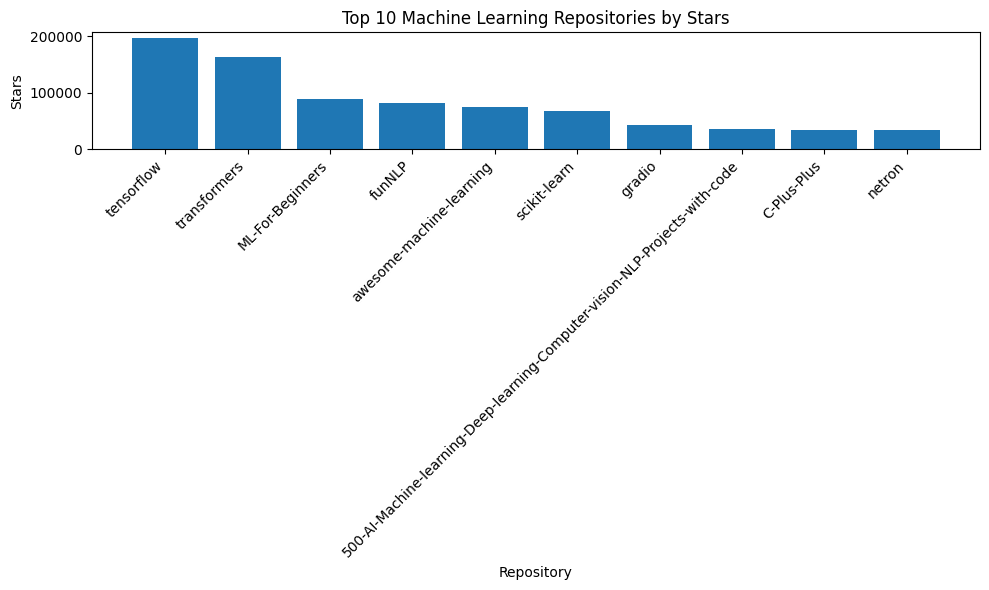

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(top_10["name"], top_10["stars"])

plt.title("Top 10 Machine Learning Repositories by Stars")
plt.xlabel("Repository")
plt.ylabel("Stars")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [ ]:
df["created_year"] = df["created_date"].dt.year

In [ ]:
creation_trends = (
    df.groupby("created_year")
      .size()
      .reset_index(name="repository_count")
)

creation_trends

,created_year,repository_count
0,2009,1
1,2010,2
2,2011,2
3,2013,3
4,2014,6
5,2015,7
6,2016,14
7,2017,17
8,2018,18
9,2019,7


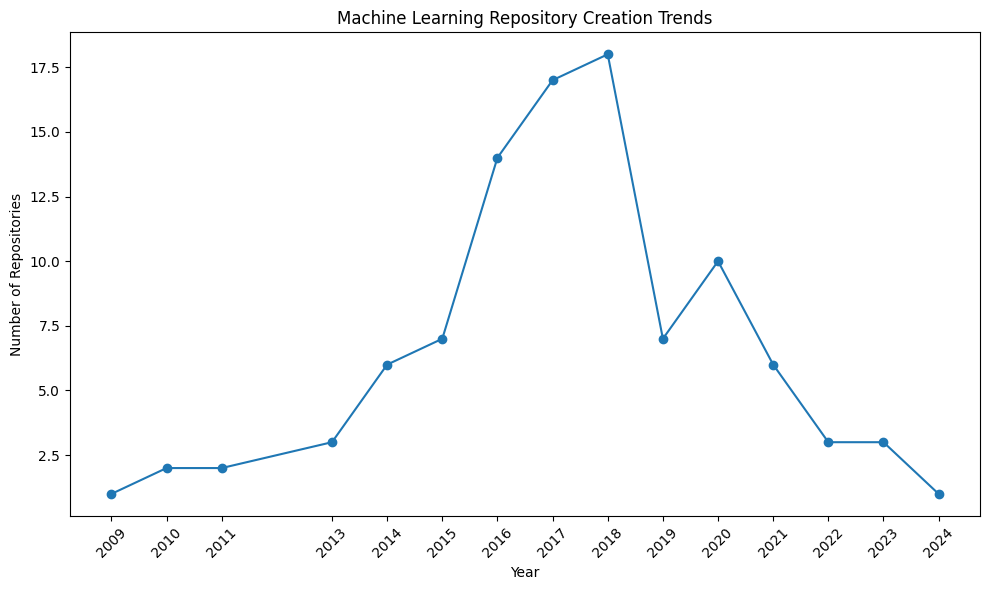

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    creation_trends["created_year"],
    creation_trends["repository_count"],
    marker="o"
)

plt.title("Machine Learning Repository Creation Trends")
plt.xlabel("Year")
plt.ylabel("Number of Repositories")

plt.xticks(creation_trends["created_year"], rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
summary

,total_repositories,average_stars
0,100,20822.23


In [ ]:
top_10

,name,owner,language,stars
0,tensorflow,tensorflow,C++,197330
1,transformers,huggingface,Python,164344
2,ML-For-Beginners,microsoft,Jupyter Notebook,89688
3,funNLP,fighting41love,Python,82598
4,awesome-machine-learning,josephmisiti,Python,74119
5,scikit-learn,scikit-learn,Python,67011
6,gradio,gradio-app,Python,43405
7,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,36454
8,C-Plus-Plus,TheAlgorithms,C++,34592
9,netron,lutzroeder,JavaScript,33387


In [ ]:
language_counts

,language,repository_count
0,Python,30
1,Unknown,23
2,Jupyter Notebook,19
3,C++,12


In [ ]:
creation_trends

,created_year,repository_count
0,2009,1
1,2010,2
2,2011,2
3,2013,3
4,2014,6
5,2015,7
6,2016,14
7,2017,17
8,2018,18
9,2019,7


In [ ]:
top_repository = top_10.iloc[0]

top_repository

,0
name,tensorflow
owner,tensorflow
language,C++
stars,197330


In [ ]:
most_common_language = language_counts.iloc[0]

most_common_language

,0
language,Python
repository_count,30


In [ ]:
peak_creation_year = creation_trends.loc[
    creation_trends["repository_count"].idxmax()
]

peak_creation_year

,8
created_year,2018
repository_count,18


In [ ]:
top_10[["name", "stars"]]

,name,stars
0,tensorflow,197330
1,transformers,164344
2,ML-For-Beginners,89688
3,funNLP,82598
4,awesome-machine-learning,74119
5,scikit-learn,67011
6,gradio,43405
7,500-AI-Machine-learning-Deep-learning-Computer...,36454
8,C-Plus-Plus,34592
9,netron,33387


In [ ]:
summary

,total_repositories,average_stars
0,100,20822.23


In [ ]:
top_10

,name,owner,language,stars
0,tensorflow,tensorflow,C++,197330
1,transformers,huggingface,Python,164344
2,ML-For-Beginners,microsoft,Jupyter Notebook,89688
3,funNLP,fighting41love,Python,82598
4,awesome-machine-learning,josephmisiti,Python,74119
5,scikit-learn,scikit-learn,Python,67011
6,gradio,gradio-app,Python,43405
7,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,36454
8,C-Plus-Plus,TheAlgorithms,C++,34592
9,netron,lutzroeder,JavaScript,33387


In [ ]:
summary

,total_repositories,average_stars
0,100,20822.23


### Insight 1: Repository Popularity

The dataset contains 100 Machine Learning repositories. The average number of stars is 20,822.23, showing that the repositories in the dataset have attracted a significant amount of attention from GitHub users.

In [ ]:
top_10.iloc[0]

,0
name,tensorflow
owner,tensorflow
language,C++
stars,197330


### Insight 2: Most Popular Repository

TensorFlow is the most popular repository in the dataset, with 197,330 stars. This is approximately 9.5 times the average number of stars across the 100 repositories, which shows that TensorFlow has significantly higher popularity than the typical repository in this dataset.

In [ ]:
language_counts

,language,repository_count
0,Python,30
1,Unknown,23
2,Jupyter Notebook,19
3,C++,12


### Insight 3: Programming Languages

Python is the most common programming language in the dataset, appearing in 30 out of 100 repositories. This means that Python represents 30% of the repositories in the dataset, making it the most frequently identified programming language among the selected Machine Learning repositories.

The dataset also contains 23 repositories with an unknown language, which means that the GitHub API did not provide a programming language value for these repositories.

In [ ]:
creation_trends

,created_year,repository_count
0,2009,1
1,2010,2
2,2011,2
3,2013,3
4,2014,6
5,2015,7
6,2016,14
7,2017,17
8,2018,18
9,2019,7


### Insight 4: Repository Creation Trends

Repository creation increased noticeably between 2014 and 2018, reaching its highest point in 2018 with 18 repositories. After 2018, the number of repositories created per year generally decreased, with 7 repositories in 2019 and 6 in 2021. The number decreased further to 3 repositories in both 2022 and 2023, and only 1 repository in 2024.

This trend suggests that the selected repositories in the dataset are concentrated around the 2016–2018 period.

In [ ]:
from google.colab import files

files.download("github_projects.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("github_projects.db")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Github Repo Link:
[Github Repo](https://github.com/Ahmed0sama2011/github-machine-learning-analysis)

# Ethics Reflection

### Question 1: What ethical considerations should be taken into account when collecting data from GitHub?

When collecting data from GitHub, it is important to use publicly available data responsibly and respect GitHub's terms and policies. The data should only be collected for a clear and appropriate purpose. In this project, the analysis focuses on public repository information such as repository names, programming languages, stars, forks, issues, dates, owners, and licenses. No private or sensitive personal information was intentionally collected.

### Question 2: How should the data be used responsibly?

The data should be used only for analysis and educational purposes and should not be used to make unfair assumptions about repository owners or developers. For example, a repository having fewer stars does not necessarily mean that it is of lower quality. The results should be interpreted based on the available data and not treated as absolute conclusions.

### Question 3: What are some limitations or possible biases in this dataset?

The dataset contains the top 100 repositories returned by a GitHub search for "machine learning", sorted by stars. Therefore, it does not represent all machine learning repositories on GitHub. Popular repositories are more likely to appear in the dataset, which can create popularity bias. Also, some repositories have missing values for programming language or license, so these missing values were handled during data cleaning.

### Question 4: How can you avoid misleading conclusions from the analysis?

To avoid misleading conclusions, I should clearly explain what the data represents and avoid generalizing the results to all GitHub repositories. The visualizations and SQL results should be reported accurately, and conclusions should be supported by the actual values in the dataset. For example, the fact that Python is the most common language in this dataset does not mean that Python is the most common language across all machine learning repositories on GitHub.

### Question 5: What responsible data practices were followed in this project?

In this project, the data was collected from the GitHub API, cleaned before analysis, and missing values were handled using appropriate replacements such as "Unknown" and "No License". Duplicate records were also checked and removed. The analysis was based on public repository information, and the results were interpreted according to the limitations of the selected dataset.